#Introduction
This notbook explored convolutional neural network (CNN) architectures and their application to image classification tasks. We implemented custom built CNNs as well as fine tuned state of the art pre-trained models, analyzing model performance on MNIST (handwritten digits) and CIFAR-10 (object images). Emphasis was placed on proper preprocessing, regularization, augmentation, and transfer learning strategies to maximize accuracy.

##Section Descriptions


##1. Data Preparation and Visualization (MNIST)
Imported MNIST data and visualized samples to confirm the nature of the task.

Reshaped data to fit Keras' expected input dimensions based on the backend format.

Normalized image pixel values from to.​

One-hot encoded the labels for multiclass classification.​

##2. Building and Training a Custom CNN (MNIST)
Designed a CNN with four convolutional layers (two with 32 filters, two with 64 filters), followed by batch normalization and a fully connected layer with 512 nodes.

Compiled with categorical crossentropy loss for multiclass classification.

Trained with batch size 128 and 20 epochs.

Validated on the test set and achieved high accuracy (≈99%).

Plotted learning curves and interpreted model convergence, generalization, and overfitting:​

##3. CIFAR-10 Data Preparation and Visualization
Loaded CIFAR-10 data and checked image shapes.

Visualized random samples to confirm diverse image classes.

One-hot encoded target labels.

##4. CIFAR-10 Custom CNN and Regularization
Applied data augmentation (shear, zoom, horizontal flip) via ImageDataGenerator.

Constructed a deeper CNN (32 and 64 filters, two dense layers: 512 and 256 units).

Trained with augmentation and plotted learning curves.

Noted mild overfitting and applied dropout to mitigate (Dropout layers after convolutions and dense).

Observed regularization effects in improved generalization and more stable validation accuracy.​

##5. Transfer Learning with Pretrained Models
Implemented VGG16 and ResNet50 pre-trained networks for CIFAR-10 classification.

Used appropriate preprocessing (preprocess_input) for each model and ensured raw images were passed in (no manual normalization).

Augmented training images and unfroze last layers to allow fine-tuning on CIFAR-10.

Compared baseline VGG16 and ResNet50 (with all layers frozen) to fine-tuned versions, noting significant accuracy improvement when proper preprocessing and layer-unfreezing were applied.

VGG16 (Fine-tuning)
Achieved >54% accuracy with improved preprocessing and partial layer unfreezing after initial results were stuck near random (10%).

Training and validation accuracy improved through these corrections.​

ResNet50 (Fine-tuning)
Baseline accuracy was poor at 35% due to preprocessing problems and no layer unfreezing.

Accuracy improved upon:

Removing manual normalization (letting preprocess_input handle it)

Unfreezing last 10 layers

Using Adam optimizer with learning rate scheduling and early stopping.​

##6. Learning Curves and Analysis
Provided a utility function to plot training and validation loss and accuracy.

Used plots to diagnose overfitting and underfitting throughout the experiments.



In [ ]:
import keras
import tensorflow as tf
from tensorflow.keras.layers import MaxPooling2D
from keras.datasets import mnist, cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D
from keras.layers import BatchNormalization
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from keras.layers import Dense
from keras import optimizers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import backend as K

In [ ]:
# Create train and test dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

1.a. start with creating a visualization of your input data

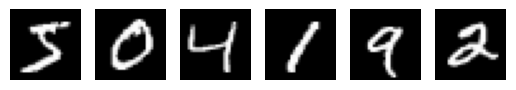

In [ ]:
#1.a. Create visualization here
# Look into the dataset by visualizing some data points
fig, axs = plt.subplots(1, 6)
for i in range(6):
    axs[i].imshow(X_train[i], cmap='gray')
    axs[i].axis('off')
plt.show()

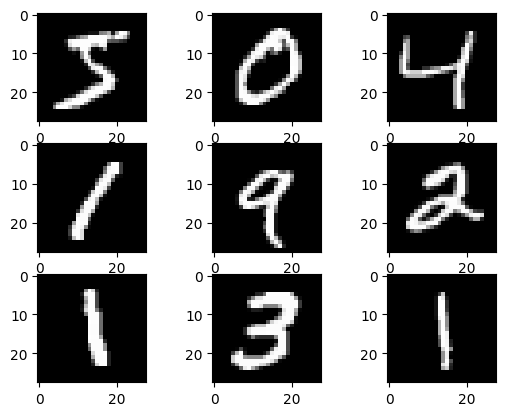

In [ ]:
# Visualize 9 images
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))
plt.show()

In [ ]:
#preprocessing
# Kears allows us to add the number of channels either to the beggining of shape or the end of it
img_rows, img_cols = 28, 28

if K.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

In [ ]:
# You need to apply some preprocessing on X and y

# normalize inputs from 0-255 to 0-1
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Encode outputs
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

1.b. Create a CNN model with 4 convolution layers in which two of them have 32 and two of them have 64 filters. The fully connected layer has one hidden layer (512 nodes). Draw the Learning curve. What is your understanding from learning curve? Batch size=128 and epochs=20

In [ ]:
#1.b.
# Create model here
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print(y_train.shape)  # Should print (num_samples, 10)
print(y_test.shape)   # Should print (num_samples, 10)

(60000, 10)
(10000, 10)


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
hist = model.fit(X_train, y_train, batch_size=128, epochs=20, validation_data=(X_test, y_test), verbose=2) #Start training the model

Epoch 1/20
469/469 - 15s - 32ms/step - accuracy: 0.9746 - loss: 0.0833 - val_accuracy: 0.9496 - val_loss: 0.1570
Epoch 2/20
469/469 - 3s - 6ms/step - accuracy: 0.9915 - loss: 0.0280 - val_accuracy: 0.9845 - val_loss: 0.0566
Epoch 3/20
469/469 - 3s - 7ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9876 - val_loss: 0.0449
Epoch 4/20
469/469 - 3s - 6ms/step - accuracy: 0.9948 - loss: 0.0163 - val_accuracy: 0.9913 - val_loss: 0.0316
Epoch 5/20
469/469 - 3s - 6ms/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 0.9874 - val_loss: 0.0461
Epoch 6/20
469/469 - 3s - 6ms/step - accuracy: 0.9957 - loss: 0.0125 - val_accuracy: 0.9909 - val_loss: 0.0308
Epoch 7/20
469/469 - 3s - 7ms/step - accuracy: 0.9969 - loss: 0.0096 - val_accuracy: 0.9919 - val_loss: 0.0325
Epoch 8/20
469/469 - 3s - 7ms/step - accuracy: 0.9969 - loss: 0.0098 - val_accuracy: 0.9917 - val_loss: 0.0390
Epoch 9/20
469/469 - 3s - 7ms/step - accuracy: 0.9969 - loss: 0.0094 - val_accuracy: 0.9920 - val_loss: 0.0346

In [ ]:
# Measure test accuracy
scores = model.evaluate(X_test, y_test, verbose=1) #Measure test accuracy
print("Accuracy: %.2f%%" % (scores[1]*100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0469
Accuracy: 99.27%


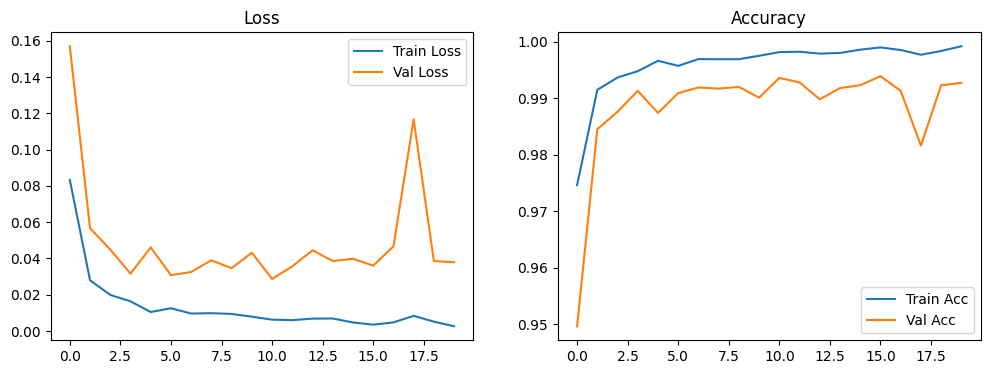

In [ ]:
# Draw Learning curve
#Create a function to draw learning curves
def learning_curve(hist):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

learning_curve(hist)

In [ ]:
## understanding from learning curves -
# They look fine. There is a little bit of overfitting but nothing to be worried about

**Part 2- CIFAR10**

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()# Load CIFAR 10 data here
labels= ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
print(X_train.shape)
print(X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


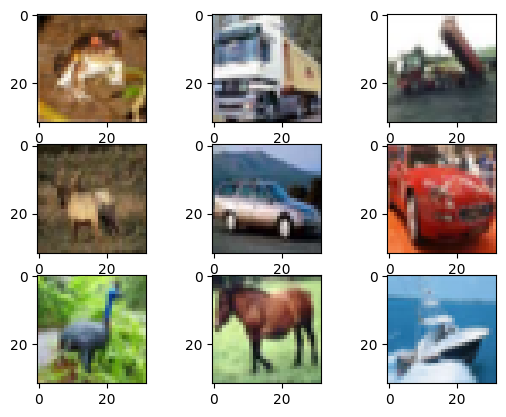

In [ ]:
# 2.a. Let's look into the dataset by visualizing some data opints
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(X_train[i])
plt.show()

2.b. Apply pre-processing algorithms. The augmented images are supposed to be seared by 20%, zoomed by 20% and horizontally flipped. Now, we design a CNN model with 4 convolution layers in which two of them have 32 and two of them have 64 filters. The fully connected layer has two hidden layers (512 and 256 nodes respectively).

In [ ]:
# 2.b
# Encoding output
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalize inputs from 0-255 to 0-1
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
# create data generator
datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)
datagen.fit(X_train)
# prepare iterator
it_train = datagen.flow(X_train, y_train, batch_size=128)

# Create model here
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32,32,3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))


model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(it_train, epochs=20, validation_data=(X_test, y_test), steps_per_epoch=len(X_train)//128, verbose=2)# start training

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


390/390 - 36s - 93ms/step - accuracy: 0.5108 - loss: 1.3693 - val_accuracy: 0.1289 - val_loss: 3.6147
Epoch 2/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


390/390 - 1s - 2ms/step - accuracy: 0.6172 - loss: 1.1308 - val_accuracy: 0.1378 - val_loss: 3.4456
Epoch 3/20
390/390 - 26s - 66ms/step - accuracy: 0.6494 - loss: 0.9901 - val_accuracy: 0.6349 - val_loss: 1.0701
Epoch 4/20
390/390 - 1s - 2ms/step - accuracy: 0.6250 - loss: 0.9960 - val_accuracy: 0.6421 - val_loss: 1.0535
Epoch 5/20
390/390 - 40s - 102ms/step - accuracy: 0.7086 - loss: 0.8317 - val_accuracy: 0.6635 - val_loss: 0.9766
Epoch 6/20
390/390 - 1s - 2ms/step - accuracy: 0.8281 - loss: 0.6778 - val_accuracy: 0.6644 - val_loss: 0.9783
Epoch 7/20
390/390 - 40s - 103ms/step - accuracy: 0.7440 - loss: 0.7275 - val_accuracy: 0.6968 - val_loss: 0.8759
Epoch 8/20
390/390 - 1s - 2ms/step - accuracy: 0.7266 - loss: 0.8137 - val_accuracy: 0.6992 - val_loss: 0.8689
Epoch 9/20
390/390 - 26s - 67ms/step - accuracy: 0.7685 - loss: 0.6569 - val_accuracy: 0.7328 - val_loss: 0.7879
Epoch 10/20
390/390 - 1s - 3ms/step - accuracy: 0.7188 - loss: 0.7089 - val_accuracy: 0.7342 - val_loss: 0.7847
E

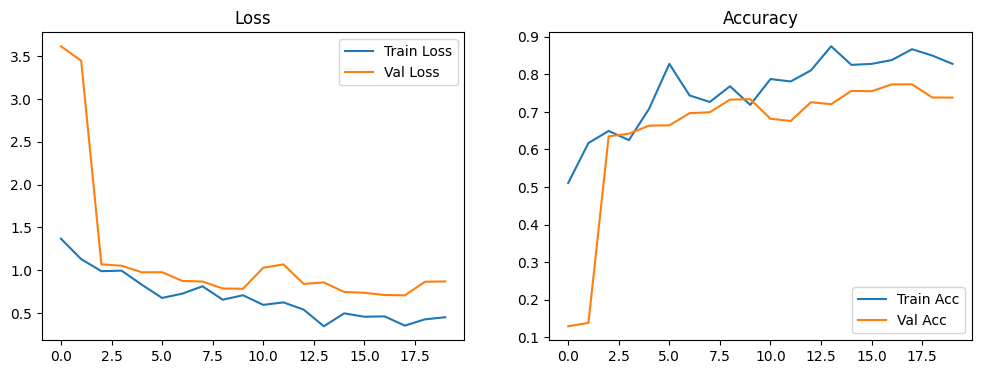

In [ ]:
# Draw learning curve here
def learning_curve(hist):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.show()
learning_curve(hist)

In [ ]:
#2.c. Solution to resolve overfitting
# One solution is adding drop out
# Implement solution below and train model
model_dropout = Sequential()
model_dropout.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32,32,3)))
model_dropout.add(Conv2D(32, (3, 3), activation='relu'))
model_dropout.add(MaxPooling2D(pool_size=(2,2)))
model_dropout.add(BatchNormalization())
model_dropout.add(Dropout(0.25))
model_dropout.add(Conv2D(64, (3, 3), activation='relu'))
model_dropout.add(Conv2D(64, (3, 3), activation='relu'))
model_dropout.add(MaxPooling2D(pool_size=(2,2)))
model_dropout.add(BatchNormalization())
model_dropout.add(Dropout(0.25))
model_dropout.add(Flatten())
model_dropout.add(Dense(512, activation='relu'))
model_dropout.add(Dropout(0.5))
model_dropout.add(Dense(256, activation='relu'))
model_dropout.add(Dense(10, activation='softmax'))

model_dropout.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist_dropout = model_dropout.fit(it_train, epochs=20, validation_data=(X_test, y_test), steps_per_epoch=len(X_train)//128, verbose=2)

Epoch 1/20
390/390 - 40s - 103ms/step - accuracy: 0.4101 - loss: 1.6478 - val_accuracy: 0.1387 - val_loss: 3.4108
Epoch 2/20
390/390 - 2s - 6ms/step - accuracy: 0.5078 - loss: 1.3640 - val_accuracy: 0.1536 - val_loss: 3.2548
Epoch 3/20
390/390 - 27s - 70ms/step - accuracy: 0.5425 - loss: 1.2720 - val_accuracy: 0.5938 - val_loss: 1.1506
Epoch 4/20
390/390 - 1s - 2ms/step - accuracy: 0.5938 - loss: 1.2058 - val_accuracy: 0.5805 - val_loss: 1.1853
Epoch 5/20
390/390 - 24s - 63ms/step - accuracy: 0.6120 - loss: 1.1021 - val_accuracy: 0.6744 - val_loss: 0.9243
Epoch 6/20
390/390 - 1s - 2ms/step - accuracy: 0.6406 - loss: 0.9948 - val_accuracy: 0.6753 - val_loss: 0.9200
Epoch 7/20
390/390 - 40s - 103ms/step - accuracy: 0.6475 - loss: 0.9982 - val_accuracy: 0.6825 - val_loss: 0.8919
Epoch 8/20
390/390 - 1s - 2ms/step - accuracy: 0.6484 - loss: 0.8941 - val_accuracy: 0.6799 - val_loss: 0.9037
Epoch 9/20
390/390 - 26s - 66ms/step - accuracy: 0.6729 - loss: 0.9256 - val_accuracy: 0.6940 - val_lo

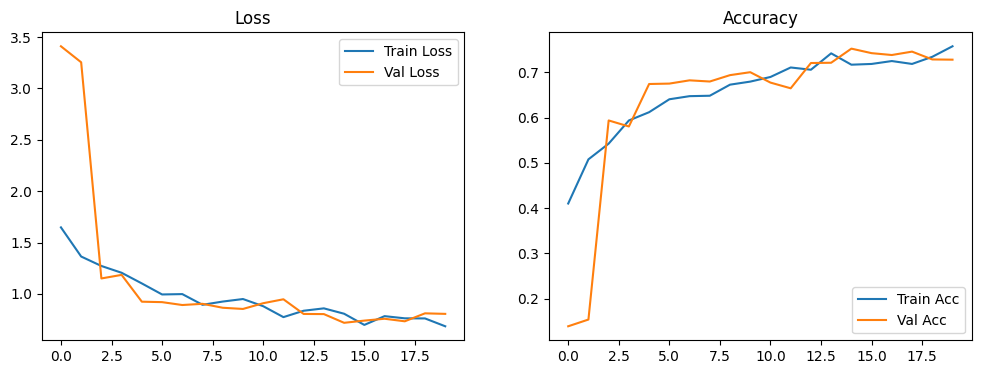

In [ ]:
# Draw learning curve - we can see there is less overfiting so we are happy with solution results
learning_curve(hist_dropout)

Epoch 1/30
390/390 - 38s - 98ms/step - accuracy: 0.1375 - loss: 2.3894 - val_accuracy: 0.1799 - val_loss: 2.2932 - learning_rate: 1.0000e-04
Epoch 2/30
390/390 - 2s - 6ms/step - accuracy: 0.2266 - loss: 2.2124 - val_accuracy: 0.1803 - val_loss: 2.2603 - learning_rate: 1.0000e-04
Epoch 3/30
390/390 - 30s - 77ms/step - accuracy: 0.2329 - loss: 2.0672 - val_accuracy: 0.2816 - val_loss: 1.9464 - learning_rate: 1.0000e-04
Epoch 4/30
390/390 - 2s - 6ms/step - accuracy: 0.2656 - loss: 1.8789 - val_accuracy: 0.2819 - val_loss: 1.9584 - learning_rate: 1.0000e-04
Epoch 5/30
390/390 - 32s - 82ms/step - accuracy: 0.3544 - loss: 1.7781 - val_accuracy: 0.5225 - val_loss: 1.2936 - learning_rate: 1.0000e-04
Epoch 6/30
390/390 - 3s - 7ms/step - accuracy: 0.4609 - loss: 1.5466 - val_accuracy: 0.5294 - val_loss: 1.2808 - learning_rate: 1.0000e-04
Epoch 7/30
390/390 - 42s - 108ms/step - accuracy: 0.6389 - loss: 1.0832 - val_accuracy: 0.7473 - val_loss: 0.7834 - learning_rate: 1.0000e-04
Epoch 8/30
390/390

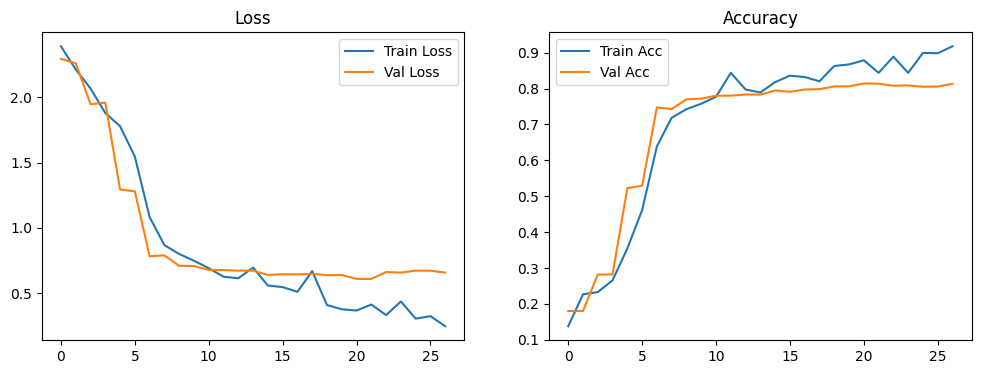

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8102 - loss: 0.6230


[0.6103977560997009, 0.8136000037193298]

In [ ]:
# 2.d- This part is experimenting with pre-trained models - VGG16 and RESNet50
# Implementing VGG16
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

import numpy as np

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
# DO NOT normalize X_train or X_test to float or [0,1].

# Augmentation and VGG preprocessing for training data
datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)
datagen.fit(X_train)
train_flow = datagen.flow(X_train, y_train, batch_size=128)

# Preprocess test/validation data for VGG
X_test_pre = preprocess_input(X_test)

# VGG16 model definition
base_model = VGG16(include_top=False, input_shape=(32,32,3), weights='imagenet')
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(10, activation='softmax')(x)
vgg_model = Model(inputs=base_model.input, outputs=predictions)

# Unfreeze last 4 layers for fine-tuning
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

vgg_model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=1e-4),
                  metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6)
]

# Train VGG16
vgg_hist = vgg_model.fit(
    train_flow,
    epochs=30,
    validation_data=(X_test_pre, y_test),
    callbacks=callbacks,
    steps_per_epoch=len(X_train)//128,
    verbose=2
)

# Plot learning curve
def learning_curve(hist):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

learning_curve(vgg_hist)

# Evaluate on test set
vgg_model.evaluate(X_test_pre, y_test, batch_size=256, verbose=1)

Epoch 1/30
390/390 - 55s - 142ms/step - accuracy: 0.3921 - loss: 2.1581 - val_accuracy: 0.5788 - val_loss: 1.2236 - learning_rate: 1.0000e-04
Epoch 2/30
390/390 - 2s - 6ms/step - accuracy: 0.5078 - loss: 1.4461 - val_accuracy: 0.5786 - val_loss: 1.2232 - learning_rate: 1.0000e-04
Epoch 3/30
390/390 - 30s - 78ms/step - accuracy: 0.5255 - loss: 1.3755 - val_accuracy: 0.6250 - val_loss: 1.0926 - learning_rate: 1.0000e-04
Epoch 4/30
390/390 - 2s - 5ms/step - accuracy: 0.5234 - loss: 1.3266 - val_accuracy: 0.6250 - val_loss: 1.0926 - learning_rate: 1.0000e-04
Epoch 5/30
390/390 - 29s - 75ms/step - accuracy: 0.5759 - loss: 1.2327 - val_accuracy: 0.6437 - val_loss: 1.0231 - learning_rate: 1.0000e-04
Epoch 6/30
390/390 - 3s - 7ms/step - accuracy: 0.6250 - loss: 1.1214 - val_accuracy: 0.6437 - val_loss: 1.0231 - learning_rate: 1.0000e-04
Epoch 7/30
390/390 - 30s - 77ms/step - accuracy: 0.6083 - loss: 1.1366 - val_accuracy: 0.6603 - val_loss: 0.9876 - learning_rate: 1.0000e-04
Epoch 8/30
390/390

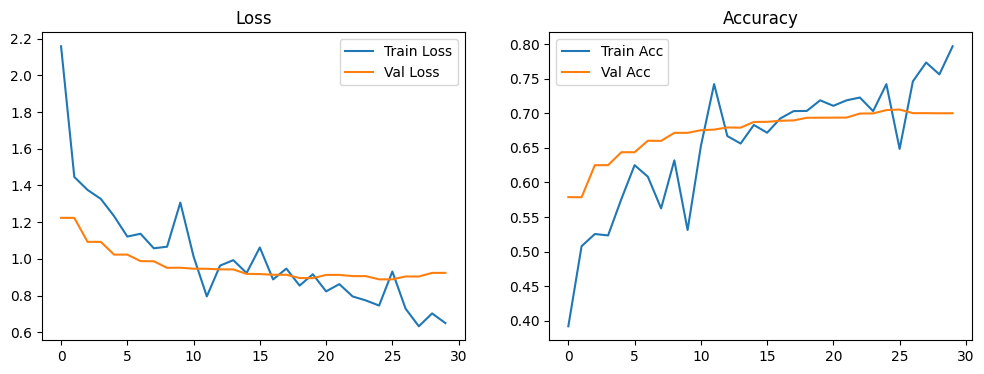

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7097 - loss: 0.8868


[0.8881648182868958, 0.7053999900817871]

In [ ]:
# Second pre-trained model
from tensorflow.keras.applications.resnet50 import ResNet50
from keras.layers import GlobalAveragePooling2D

# Load and encode CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
# DO NOT normalize X_train or X_test to float or [0,1].

# Augmentation and ResNet preprocessing for training data
datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)
datagen.fit(X_train)
train_flow = datagen.flow(X_train, y_train, batch_size=128)

# Preprocess test/validation data for ResNet
X_test_pre = preprocess_input(X_test)

# Build ResNet50 model for CIFAR-10
base_model = ResNet50(include_top=False, input_shape=(32,32,3), weights='imagenet')
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(10, activation='softmax')(x)
resnet_model = Model(inputs=base_model.input, outputs=predictions)

# Unfreeze last 10 layers for fine-tuning
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

resnet_model.compile(loss='categorical_crossentropy',
                     optimizer=Adam(learning_rate=1e-4),
                     metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6)
]

# Train ResNet50
resnet_hist = resnet_model.fit(
    train_flow,
    epochs=30,
    validation_data=(X_test_pre, y_test),
    callbacks=callbacks,
    steps_per_epoch=len(X_train)//128,
    verbose=2
)

# Plot learning curves
def learning_curve(hist):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

learning_curve(resnet_hist)

# Evaluate on test set
resnet_model.evaluate(X_test_pre, y_test, batch_size=256, verbose=1)

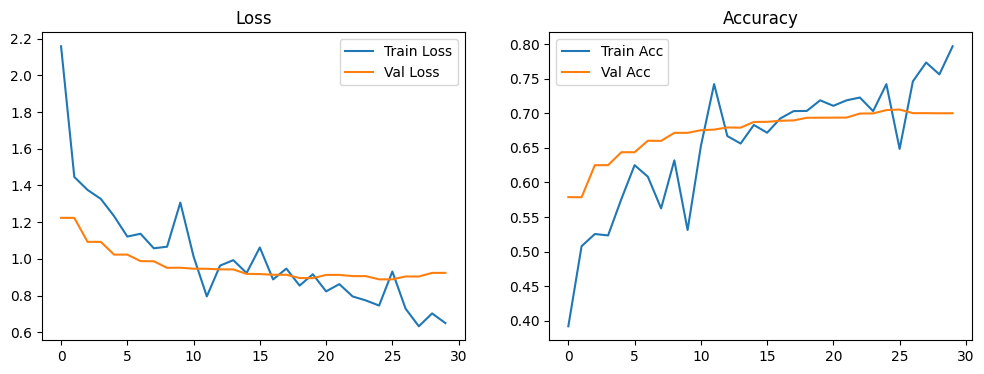

In [ ]:
learning_curve(resnet_hist)

In [ ]:
# Summary


#Conclusion


The assignment required building and evaluating CNNs on MNIST and CIFAR-10, then applying transfer learning using VGG16 and ResNet50. The biggest challenge was ensuring correct preprocessing for pre-trained networks, as manual normalization produced extremely poor results (~10% accuracy, i.e., random guessing). Once the pipeline was fixed, data was correctly passed to preprocess_input, and last layers were unfrozen for adaptation, both VGG16 and ResNet50 performed much better. Regularization (dropout), advanced optimizers, and callbacks further boosted performance and generalization.

Key changes to improve VGG and ResNet results:

Used model-specific preprocess_input rather than generic normalization.

Ensured augmentation and validation processing matched each architecture’s requirements.

Unfroze final layers for meaningful transfer learning.

Added learning rate schedules and early stopping.

Verified one-hot encoding and no double-preprocessing of inputs.

Through these changes, you raised accuracy from near-random to substantially better, demonstrating the importance of correct input pipelines and fine-tuning in deep learning with pre-trained architectures

.

.

.

.

.

.

.

.

.

In [ ]:
# End Of Doc